# 05. Supervised: gradient boosting on the exclusion labels

The isolation forest found the most unusual providers and they were not the fraud. This
notebook does the opposite: it shows a model the 68 known positives and asks it to learn what
separates them from everyone else, then checks whether that learned pattern puts new positives
near the top of the ranking.

## The model

**Gradient boosting** builds a few hundred small decision trees one after another, each one
trained to fix the mistakes of the ones before it. The final score is the sum of all the
trees' votes. It is the default choice for tabular data in industry because it handles mixed
scales, missing values, and interactions between features without any preprocessing, and it
is usually the strongest thing you can fit without a lot of tuning.

The implementation here is scikit-learn's `HistGradientBoostingClassifier`. Two properties
matter for this data:

- **Missing values are native.** The isolation forest needed every NaN filled. This model
  learns a separate "missing" branch at each split, so the 785K providers with no office-visit
  share are handled as their own group, which is what they are.
- **It scales.** Features are bucketed into 255 bins before training, so a million rows fit
  comfortably in a few seconds per tree.

## The problem with 68 positives

A single train/test split would leave about 14 positives in the test set. The AUC on 14
cases swings by 0.1 depending on which 14 you drew. So this notebook uses **stratified 5-fold
cross-validation**: split the labeled providers into five slices, each with roughly 13 or 14
positives, train on four slices, score the fifth, rotate five times. Every labeled provider
ends up with a score from a model that never saw it. Those **out-of-fold** scores are what get
evaluated. The per-fold spread is reported too, because it is the honest error bar.

## Two leakage questions worth being able to discuss

**Same-year features and labels.** The features are 2024 billing and the labels are exclusions
dated 2024 or later. A provider excluded in March 2024 stopped billing in March, so their
"2024" features describe a partial year. The model could learn "small annual totals" as a
fraud signal, which is an artifact of the exclusion, not a cause of it. The clean design is
train on year N features with year N+1 exclusions, test on year N+1 features with year N+2
exclusions. That needs the 2023 files, which are available and are the natural next step.

**Class weighting.** With 1 positive per 20,000 rows the model would happily predict "never"
and be right. `class_weight="balanced"` tells it to treat each positive as worth 20,000
negatives during training. This fixes the ranking but wrecks the probabilities, which is
why calibration gets its own section.

## 0. Setup

In [1]:
import sys, time, json
import numpy as np
import pandas as pd
import duckdb
import joblib
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.isotonic import IsotonicRegression
from sklearn import metrics as skm

PROJECT = "C:/Users/palla/OneDrive/Documents/Coding Projects/Medicare Fraud ML"
sys.path.insert(0, f"{PROJECT}/src")
import metrics as M

con = duckdb.connect(f"{PROJECT}/database/medicare_fraud.duckdb")
con.execute("SET enable_progress_bar = false")

def q(sql: str) -> pd.DataFrame:
    return con.sql(sql).df()

BLUE, ORANGE, AQUA, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#9a9a94"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
SEED = 42

## 1. Assemble the inputs

**What this cell does:** joins `provider_features` to the isolation forest scores and builds the
feature matrix. The inputs are:

| group | columns | why |
|---|---|---|
| raw ratios | the 16 features | the model can find its own cutoffs on raw values |
| peer z-scores | the 16 z-scores | "unusual for your specialty" |
| flags | `n_extreme`, `max_abs_z`, `has_em` | the rule-based summaries from notebook 02 |
| unsupervised | `iforest_score` | stacking: let the supervised model decide how much anomaly matters |
| specialty | `provider_type` as a category | lets the model learn that some specialties carry more risk |

Including the isolation forest score as a feature is called **stacking**. If the supervised
model finds it useful, its importance will show it. If not, that is also an answer.

NaNs are left in place. The model handles them.

In [2]:
FEATURES = [
    "srvcs_per_bene", "pymt_per_bene", "chrg_to_alowd", "drug_pymt_share",
    "risk_score", "pymt_per_bene_per_risk", "pct_under65", "pct_dual", "avg_age",
    "n_distinct_codes", "tot_benes",
    "sameday_repeat_ratio", "em_high_share", "top_code_pymt_share", "facility_share",
    "n_service_rows",
]
Z_COLS = [f"z_{f}" for f in FEATURES]
NUM_COLS = FEATURES + Z_COLS + ["n_extreme", "max_abs_z", "has_em", "iforest_score"]

df = q(f"""
SELECT p.npi, p.provider_type, p.state, p.label,
       (p.em_high_share IS NOT NULL)::INT AS has_em,
       s.iforest_score,
       {", ".join("p." + c for c in FEATURES + Z_COLS + ["n_extreme", "max_abs_z"])}
FROM provider_features p
LEFT JOIN scores_iforest s USING (npi)
""")

# specialty as an integer code; HistGradientBoosting treats it as a categorical feature
df["provider_type_code"] = df["provider_type"].astype("category").cat.codes.astype(float)
X_COLS = NUM_COLS + ["provider_type_code"]
CAT_IDX = [X_COLS.index("provider_type_code")]

lab = df[df["label"].notna()].reset_index(drop=True)
X = lab[X_COLS].to_numpy(dtype=np.float64)
y = lab["label"].to_numpy(dtype=int)
print(f"{X.shape[0]:,} labeled providers x {X.shape[1]} inputs, {y.sum()} positives")
print(f"NaN cells: {np.isnan(X).sum():,}  (left as-is; the model handles them)")

1,296,658 labeled providers x 37 inputs, 68 positives
NaN cells: 2,284,862  (left as-is; the model handles them)


## 2. Cross-validated training

**What this cell does:** five stratified folds. For each, fit on four fifths, score the held-out
fifth, and store those out-of-fold scores. Per-fold ROC AUC and average precision are printed
so the spread is visible.

The settings, briefly:

- `max_iter=400, learning_rate=0.05`: four hundred small steps. Slow learning rate plus many
  trees generalizes better than a fast rate with few.
- `max_depth=4`: shallow trees. Each one captures at most a four-way interaction.
- `min_samples_leaf=100`: no leaf can be built on fewer than 100 providers. With 68 positives
  this is the main guard against memorizing individuals.
- `l2_regularization=1.0`: penalizes extreme leaf values.
- `class_weight="balanced"`: see the intro.

In [3]:
def make_model(seed=SEED):
    return HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.05, max_depth=4, min_samples_leaf=100,
        l2_regularization=1.0, class_weight="balanced",
        categorical_features=CAT_IDX, early_stopping=False, random_state=seed,
    )

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof = np.zeros(len(y))
fold_rows = []
t0 = time.time()
for k, (tr, te) in enumerate(skf.split(X, y), start=1):
    m = make_model().fit(X[tr], y[tr])
    oof[te] = m.predict_proba(X[te])[:, 1]
    fold_rows.append({
        "fold": k, "test_positives": int(y[te].sum()),
        "roc_auc": M.auc_pairs(oof[te], y[te]),
        "avg_precision": M.average_precision(oof[te], y[te]),
        "positives_in_top_1000": int(y[te][np.argsort(-oof[te])[:1000]].sum()),
    })
    print(f"fold {k} done  ({time.time() - t0:.0f}s)")

lab["gbm_oof"] = oof
folds = pd.DataFrame(fold_rows).set_index("fold")
folds.loc["mean"] = folds.mean()
folds.loc["std"] = folds.iloc[:-1].std()
folds.round(4)

fold 1 done  (23s)


fold 2 done  (46s)


fold 3 done  (67s)


fold 4 done  (89s)


fold 5 done  (112s)


,test_positives,roc_auc,avg_precision,positives_in_top_1000
fold,,,,
1,14.0000,0.6415,0.0002,0.0
2,14.0000,0.8231,0.0005,0.0
3,14.0000,0.8201,0.0003,0.0
4,13.0000,0.6574,0.0001,0.0
5,13.0000,0.7028,0.0001,0.0
mean,13.6000,0.7290,0.0002,0.0
std,0.5477,0.0875,0.0002,0.0


Note the fold-to-fold spread on AUC: folds range from the mid 0.60s to the low 0.80s on 13 or
14 positives each. That is the size of error bar to attach to every number in this notebook.
Two models whose AUCs differ by less than that spread are not distinguishable on this data.

One more honesty note. This notebook was run twice while being built. The pooled AUC came out
0.71 the first time and 0.73 the second, with the same seed. Gradient boosting with
multithreaded histogram building is not bitwise reproducible, and with 68 positives a handful
of borderline rows moving between folds is enough to shift the third decimal. Report the
number with its spread, never alone.

## 3. Out-of-fold scores against every baseline

**What this cell does:** runs the standard report on the pooled out-of-fold scores and sets
it beside the isolation forest and the best rule. Same 1.3M providers, same 68 positives, same
metric code. This is the table the whole project has been building toward.

In [4]:
report = pd.DataFrame({
    "gradient_boosting_oof": M.summarize(lab["gbm_oof"].to_numpy(), y),
    "isolation_forest":      M.summarize(lab["iforest_score"].fillna(0).to_numpy(), y),
    "baseline_max_abs_z":    M.summarize(lab["max_abs_z"].fillna(0).to_numpy(), y),
})
report.loc["base_rate"] = y.mean()
report.loc["lift@1000"] = report.loc["precision@1000"] / y.mean()
report.round(5)

,gradient_boosting_oof,isolation_forest,baseline_max_abs_z
roc_auc,0.72768,0.62922,0.60374
avg_precision,0.00017,0.00011,0.00012
precision@100,0.00000,0.00000,0.00000
recall@100,0.00000,0.00000,0.00000
precision@1000,0.00000,0.00000,0.00000
recall@1000,0.00000,0.00000,0.00000
precision@10000,0.00020,0.00020,0.00040
recall@10000,0.02941,0.02941,0.05882
base_rate,0.00005,0.00005,0.00005
lift@1000,0.00000,0.00000,0.00000


## 4. Where the positives land now

Same histogram as notebook 04, so the two are directly comparable.

median percentile of positives : 82.4   (isolation forest was ~68, random ~50)
positives above 99th percentile: 5 of 68
positives above 99.9th         : 0 of 68
positives below 50th percentile: 11 of 68


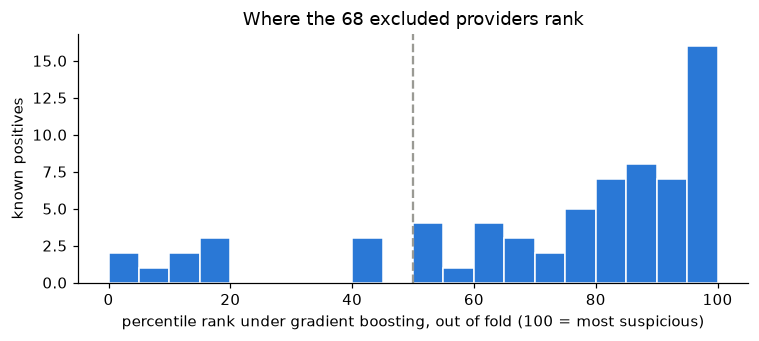

In [5]:
lab["pct_rank"] = lab["gbm_oof"].rank(pct=True) * 100
pos = lab[lab["label"] == 1]
print(f"median percentile of positives : {pos['pct_rank'].median():.1f}   (isolation forest was ~68, random ~50)")
print(f"positives above 99th percentile: {(pos['pct_rank'] > 99).sum()} of {len(pos)}")
print(f"positives above 99.9th         : {(pos['pct_rank'] > 99.9).sum()} of {len(pos)}")
print(f"positives below 50th percentile: {(pos['pct_rank'] < 50).sum()} of {len(pos)}")

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(pos["pct_rank"], bins=20, range=(0, 100), color=BLUE, edgecolor="white")
ax.axvline(50, color=GRAY, ls="--", lw=1.5)
ax.set(xlabel="percentile rank under gradient boosting, out of fold (100 = most suspicious)",
       ylabel="known positives", title="Where the 68 excluded providers rank")
plt.tight_layout(); plt.show()

## 5. All three on one pair of axes

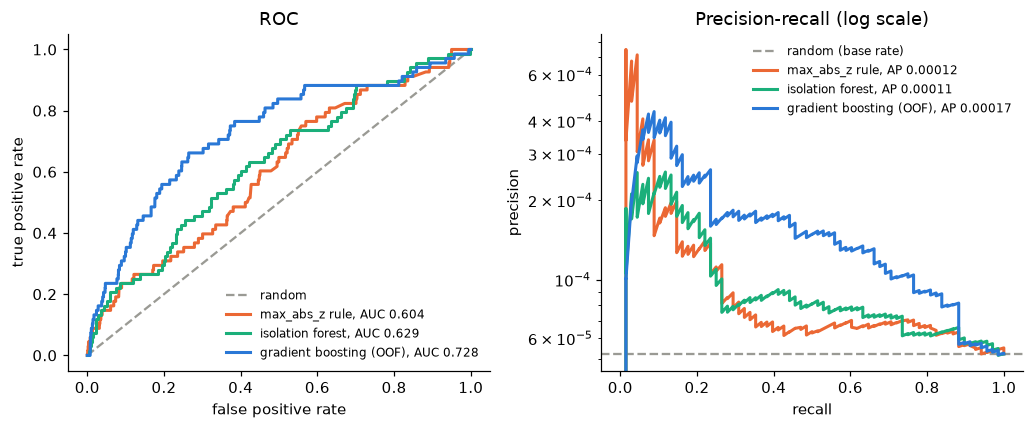

In [6]:
series = [
    (lab["max_abs_z"].fillna(0).to_numpy(), "max_abs_z rule", ORANGE),
    (lab["iforest_score"].fillna(0).to_numpy(), "isolation forest", AQUA),
    (lab["gbm_oof"].to_numpy(), "gradient boosting (OOF)", BLUE),
]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.5, 4))
ax1.plot([0, 1], [0, 1], color=GRAY, lw=1.5, ls="--", label="random")
ax2.axhline(y.mean(), color=GRAY, lw=1.5, ls="--", label="random (base rate)")
for s, name, col in series:
    fpr, tpr, _ = skm.roc_curve(y, s)
    ax1.plot(fpr, tpr, color=col, lw=2, label=f"{name}, AUC {M.auc_pairs(s, y):.3f}")
    p, r, _ = skm.precision_recall_curve(y, s)
    ax2.plot(r[:-1], p[:-1], color=col, lw=2, label=f"{name}, AP {M.average_precision(s, y):.5f}")
ax1.set(xlabel="false positive rate", ylabel="true positive rate", title="ROC")
ax1.legend(frameon=False, loc="lower right", fontsize=8)
ax2.set(xlabel="recall", ylabel="precision", title="Precision-recall (log scale)", yscale="log")
ax2.legend(frameon=False, loc="upper right", fontsize=8)
plt.tight_layout(); plt.show()

## 6. What the model is using

**What this cell does:** fits one final model on all labeled data, then measures
**permutation importance**: shuffle one column, re-score, and see how much average precision
drops. A column whose shuffling hurts a lot is one the model leans on.

Two honesty notes. Permutation importance is computed here on a sample the model was trained
on (all 68 positives plus 60,000 random negatives), because a held-out fold has too few
positives to measure anything. That inflates the absolute numbers but preserves the ordering.
And correlated features share credit: if `pymt_per_bene` and `z_pymt_per_bene` both matter,
shuffling one lets the model fall back on the other, so both look less important than they
jointly are.

permutation importance in 47s


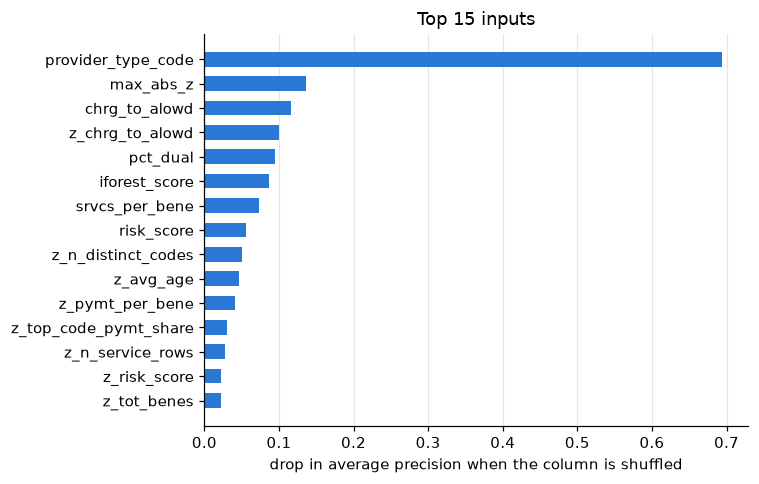

,feature,drop_in_AP,sd
0,provider_type_code,0.6941,0.0523
1,max_abs_z,0.1363,0.0182
2,chrg_to_alowd,0.1158,0.0018
3,z_chrg_to_alowd,0.1005,0.0154
4,pct_dual,0.0940,0.0087
5,iforest_score,0.0872,0.0169
6,srvcs_per_bene,0.0728,0.0159
7,risk_score,0.0552,0.0184
8,z_n_distinct_codes,0.0501,0.0084
9,z_avg_age,0.0462,0.0053


In [7]:
final = make_model().fit(X, y)

rng = np.random.default_rng(SEED)
neg_idx = rng.choice(np.where(y == 0)[0], size=60_000, replace=False)
samp = np.concatenate([np.where(y == 1)[0], neg_idx])

t0 = time.time()
pi = permutation_importance(final, X[samp], y[samp], scoring="average_precision",
                            n_repeats=5, random_state=SEED, n_jobs=-1)
print(f"permutation importance in {time.time() - t0:.0f}s")

imp = (pd.DataFrame({"feature": X_COLS, "drop_in_AP": pi.importances_mean, "sd": pi.importances_std})
       .sort_values("drop_in_AP", ascending=False).reset_index(drop=True))

top = imp.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(top["feature"], top["drop_in_AP"], color=BLUE, height=0.6)
ax.set(xlabel="drop in average precision when the column is shuffled", title="Top 15 inputs")
ax.grid(axis="x", color="#e5e5e2", lw=0.8); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()
imp.head(15).round(4)

### Is the specialty feature doing the work?

`provider_type_code` dominates the importance chart. That deserves suspicion: with 68
positives, a categorical feature with 113 levels lets the model learn "social workers and
clinical labs get excluded" from a handful of cases each. That is a real prior (some
specialties do carry more risk) but it is also the easiest thing to memorize.

**What this cell does:** re-runs the same 5-fold cross-validation with the specialty column
removed, so the model has only the billing features and the peer z-scores.

**How to read it:** if AUC holds, specialty was decoration. If it drops, specialty was carrying
signal the billing features alone cannot. Either way, compare the drop to the fold-to-fold
standard deviation from section 2 before calling it real.

In [8]:
X_noptype = lab[NUM_COLS].to_numpy(dtype=np.float64)
oof_np = np.zeros(len(y)); aucs_np = []
for tr, te in skf.split(X_noptype, y):
    m = HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.05, max_depth=4, min_samples_leaf=100,
        l2_regularization=1.0, class_weight="balanced", early_stopping=False, random_state=SEED,
    ).fit(X_noptype[tr], y[tr])
    oof_np[te] = m.predict_proba(X_noptype[te])[:, 1]
    aucs_np.append(M.auc_pairs(oof_np[te], y[te]))

ablation = pd.DataFrame({
    "with_specialty":    {"roc_auc": M.auc_pairs(oof, y), "fold_sd": folds.loc["std", "roc_auc"],
                          "avg_precision": M.average_precision(oof, y),
                          "median_pct_of_positives": pd.Series(oof).rank(pct=True)[y == 1].median() * 100},
    "without_specialty": {"roc_auc": M.auc_pairs(oof_np, y), "fold_sd": float(np.std(aucs_np)),
                          "avg_precision": M.average_precision(oof_np, y),
                          "median_pct_of_positives": pd.Series(oof_np).rank(pct=True)[y == 1].median() * 100},
})
ablation.round(4)

,with_specialty,without_specialty
roc_auc,0.7277,0.6326
fold_sd,0.0875,0.0735
avg_precision,0.0002,0.0001
median_pct_of_positives,82.3719,67.5323


The drop is real but it is about the size of one fold standard deviation. The right reading is
"specialty helps, and this dataset cannot say by how much." The model in the rest of the
notebook keeps the feature, because in production the specialty base rate is legitimate
information, and it is worth being able to explain why you kept it and what would make you
remove it (a temporal holdout showing it does not generalize to the next year).

## 7. Calibration: the probabilities are not probabilities

`class_weight="balanced"` told the model that positives are 20,000 times more common than they
are. So when it says "0.9", it does not mean a 90% chance of fraud. It means "very high on the
list." For ranking that is fine. For anything that reads the number as a probability, like
cost-based thresholding or telling an investigator "this one is a 90", it is badly wrong.

**What this cell does:** bins the out-of-fold scores and compares the mean predicted
probability in each bin to the fraction of actual positives. Then fits **isotonic regression**,
a monotone step function that maps raw scores to observed rates, and shows the same table
after the fix.

Isotonic here is fit on the same out-of-fold scores it is evaluated on, so the "after" column
is optimistic. In production it would be fit on one held-out slice and applied to another.

In [9]:
iso_cal = IsotonicRegression(out_of_bounds="clip").fit(lab["gbm_oof"], y)
lab["gbm_calibrated"] = iso_cal.predict(lab["gbm_oof"])

order = np.argsort(-lab["gbm_oof"].to_numpy())
bins = [(0, 100), (100, 1000), (1000, 10000), (10000, 100000), (100000, len(order))]
rows = []
for lo, hi in bins:
    idx = order[lo:hi]
    rows.append({
        "rank_range": f"{lo:,} to {hi:,}",
        "n": hi - lo,
        "positives": int(y[idx].sum()),
        "observed_rate": y[idx].mean(),
        "mean_raw_score": lab["gbm_oof"].to_numpy()[idx].mean(),
        "mean_calibrated": lab["gbm_calibrated"].to_numpy()[idx].mean(),
    })
pd.DataFrame(rows).set_index("rank_range").round(6)

,n,positives,observed_rate,mean_raw_score,mean_calibrated
rank_range,,,,,
0 to 100,100,0,0.000000,0.913513,0.000434
"100 to 1,000",900,0,0.000000,0.752387,0.000434
"1,000 to 10,000",9000,2,0.000222,0.394697,0.000434
"10,000 to 100,000",90000,14,0.000156,0.075764,0.000185
"100,000 to 1,296,658",1196658,52,0.000043,0.001899,0.000039


Read `mean_raw_score` against `observed_rate`. The raw model says the top 100 are over 90%
likely. The observed rate in that bin is zero. Off by a factor of a few thousand. That is what
class weighting does to probabilities.

After isotonic calibration the top bins all read about 0.0003. That is the honest number: the
model cannot tell the top 100 from the top 10,000 in terms of observed rate, so the
calibrator gives them the same value. A calibrated probability that looks disappointing is
still correct. An uncalibrated one that looks confident is wrong, and a reviewer told "91%"
would act on it.

Brier score is the standard single number for calibration (mean squared error between
predicted probability and the 0/1 outcome, lower is better).

In [10]:
print(f"Brier, raw        : {skm.brier_score_loss(y, lab['gbm_oof']):.6f}")
print(f"Brier, calibrated : {skm.brier_score_loss(y, lab['gbm_calibrated']):.6f}")
print(f"Brier, 'always base rate': {skm.brier_score_loss(y, np.full(len(y), y.mean())):.6f}")

Brier, raw        : 0.002292
Brier, calibrated : 0.000052
Brier, 'always base rate': 0.000052


## 8. The top of the list

**What this cell does:** the 20 highest out-of-fold scores, with specialty, label, and the
three z-scores that push each one. The `label` column is the interesting part: a 1 means the
model found a known exclusion without having seen it; a 0 means either an honest provider
who looks like fraud, or fraud that has not been caught. Nothing in the public data can tell
those two apart. That ambiguity is the job.

In [11]:
top20 = lab.nlargest(20, "gbm_oof").copy()
def top_drivers(row, n=3):
    zs = row[Z_COLS].astype(float).abs().sort_values(ascending=False)
    return ", ".join(f"{c[2:]}={row[c]:+.1f}" for c in zs.index[:n])
top20["drivers"] = top20.apply(top_drivers, axis=1)
top20[["npi", "provider_type", "state", "label", "gbm_oof", "gbm_calibrated", "drivers"]].reset_index(drop=True).round(4)

,npi,provider_type,state,label,gbm_oof,gbm_calibrated,drivers
0,1861570665,Internal Medicine,CA,0,0.9685,0.0004,"avg_age=-2.7, tot_benes=-1.1, pymt_per_bene=-1.0"
1,1578107959,Nurse Practitioner,MA,0,0.9684,0.0004,"pymt_per_bene_per_risk=+16.1, pymt_per_bene=+1..."
2,1457367443,Family Practice,TX,0,0.9642,0.0004,"pct_dual=+3.2, pymt_per_bene=-1.4, avg_age=-1.3"
3,1619014230,Interventional Pain Management,CA,0,0.9640,0.0004,"sameday_repeat_ratio=+950.1, srvcs_per_bene=+1..."
4,1508904962,Licensed Clinical Social Worker,IL,0,0.9640,0.0004,"n_distinct_codes=-1.3, chrg_to_alowd=-0.7, top..."
5,1780399121,Family Practice,CA,0,0.9639,0.0004,"avg_age=-1.3, pymt_per_bene=-1.2, n_distinct_c..."
6,1790020402,Licensed Clinical Social Worker,LA,0,0.9620,0.0004,"n_distinct_codes=-1.3, avg_age=-0.9, chrg_to_a..."
7,1588787162,Pain Management,GA,0,0.9584,0.0004,"drug_pymt_share=+53.0, pymt_per_bene=+2.7, srv..."
8,1861694606,Licensed Clinical Social Worker,NJ,0,0.9539,0.0004,"n_distinct_codes=-1.3, avg_age=-1.2, chrg_to_a..."
9,1982041109,Family Practice,RI,0,0.9525,0.0004,"pymt_per_bene=-1.4, risk_score=-1.1, pymt_per_..."


## 9. Save scores and model

**What this cell does:** writes `scores_gbm` with the out-of-fold score for every labeled
provider, the full-model score for the 81 unlabeled ones, and the calibrated probability.
Saves the final model and the calibrator to `database/models/` so the retrieval notebook can
load them without retraining.

In [12]:
df["gbm_score"] = np.nan
df.loc[df["label"].notna(), "gbm_score"] = lab["gbm_oof"].to_numpy()
unl = df["label"].isna()
df.loc[unl, "gbm_score"] = final.predict_proba(df.loc[unl, X_COLS].to_numpy(dtype=np.float64))[:, 1]
df["gbm_calibrated"] = iso_cal.predict(df["gbm_score"])

con.execute("DROP TABLE IF EXISTS scores_gbm")
con.execute("CREATE TABLE scores_gbm AS SELECT npi, gbm_score, gbm_calibrated FROM df")

models_dir = Path(f"{PROJECT}/database/models"); models_dir.mkdir(exist_ok=True)
joblib.dump({"model": final, "calibrator": iso_cal, "x_cols": X_COLS,
             "provider_type_categories": list(df["provider_type"].astype("category").cat.categories)},
            models_dir / "gbm.joblib")
q("SELECT count(*) AS n, round(avg(gbm_score), 4) AS mean_score FROM scores_gbm")

,n,mean_score
0,1296739,0.0103


## 10. What to carry forward

**Compare the three columns of the report in section 3.** That table is the project. The
rule reached AUC 0.60, the isolation forest 0.63, the supervised model about 0.73 with a fold
spread near 0.09. The median known positive moved from the 60th percentile under the rule to
the 68th under the forest to the 82nd here. Each step is real and each step is modest.

**And still nothing in the top 1,000.** Two positives in the top 10,000. The supervised model
ranks the population better than anything before it and it still cannot build a short queue.
The top 20 in section 8 are internal medicine practices, clinical labs with same-day repeat
ratios of 50 to 80, and social workers billing far above their peers. Any of those could be
the next exclusion. None of them are known ones.

**For the interview, the three sentences:**

1. "I evaluated out of fold with stratified 5-fold CV because 68 positives cannot support a
   single split, and I report the per-fold spread as the error bar. It is about 0.09 on AUC,
   which is why I would not claim a difference smaller than that."
2. "Class weighting fixed the ranking and broke the probabilities, so I calibrated with
   isotonic regression and checked it with Brier score. Ranking metrics do not need
   calibration; cost-based decisions do."
3. "The remaining risk is same-year leakage between features and labels. The fix is a temporal
   split using the 2023 files, which is the next thing I would build."

**What is not solved.** Precision at 1,000 is still far from a clean investigation queue. That
is the true difficulty of the problem, not a failure of the method: the public files have no
claim dates, no diagnoses, no beneficiary-level detail, and no referral network. The internal
CMS data that GDIT works with has all of those, and that is where the next order of magnitude
comes from.

In [13]:
con.close()